In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from skimage.filters import threshold_otsu

from plots import plot_metrics

In [3]:
s = pd.read_csv('data/raw/Poland_spc.csv')
wavelengths = s.columns[1:].values.astype(float)

data = np.load("data/dataset_splits.npz")

data_proccesed = np.load("data/predictions/snv_sg1_preprocessed_spectra.npz")

X_train_raw = data['X_train']
X_test_raw = data['X_test']

X_train_processed = data_proccesed["X_train_pp"]
X_test_processed = data_proccesed["X_test_pp"]

y_train = data["y_train"]
y_test = data["y_test"]

y_train_log = np.log1p(data["y_train"])
y_test_log = np.log1p(data["y_test"])

In [4]:
np.random.seed(42)


scaler_X = StandardScaler()

X_train_raw_sc = scaler_X.fit_transform(X_train_raw)
X_test_raw_sc = scaler_X.transform(X_test_raw)


In [5]:

max_comps = 60
cv = KFold(n_splits=10, shuffle=True, random_state=42)

pipe = Pipeline([("pls", PLSRegression())])
param_grid = {"pls__n_components": range(1, max_comps + 1)}

grid_raw_y = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_raw_y.fit(X_train_raw_sc, y_train)

Fitting 10 folds for each of 60 candidates, totalling 600 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'pls__n_components': range(1, 61)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,51


In [6]:
grid_log_y = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_log_y.fit(X_train_raw_sc, y_train_log)

Fitting 10 folds for each of 60 candidates, totalling 600 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'pls__n_components': range(1, 61)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,59


In [7]:
grid_proc_x_log_y = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_proc_x_log_y.fit(X_train_processed, y_train_log)

Fitting 10 folds for each of 60 candidates, totalling 600 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'pls__n_components': range(1, 61)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,37


In [15]:
grid_proc_x = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_proc_x.fit(X_train_processed, y_train)

Fitting 10 folds for each of 60 candidates, totalling 600 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'pls__n_components': range(1, 61)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,29


In [16]:
y_pred_raw_x_raw_y = grid_raw_y.best_estimator_.predict(X_test_raw_sc)
y_pred_log_y = grid_log_y.best_estimator_.predict(X_test_raw_sc)
y_pred_log_y_proc_x = grid_proc_x_log_y.best_estimator_.predict(X_test_processed)
y_pred_proc_x = grid_proc_x.best_estimator_.predict(X_test_processed)

In [17]:
grid_raw_y.best_params_, grid_log_y.best_params_, grid_proc_x_log_y.best_params_, grid_proc_x.best_params_,

({'pls__n_components': 51},
 {'pls__n_components': 59},
 {'pls__n_components': 37},
 {'pls__n_components': 29})

We could see that the model underpredict the high values as the test still not ideal mirrors the true distribution (which is exponential)

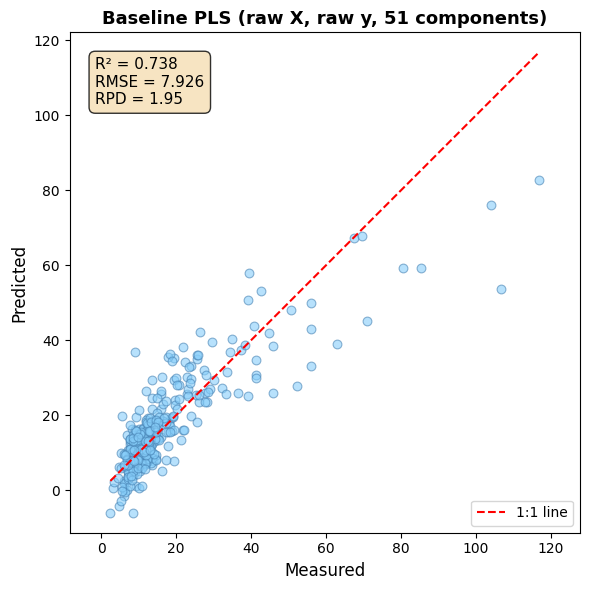

In [13]:
plot_metrics(
    y_test,
    y_pred_raw_x_raw_y,
    "Baseline PLS (raw X, raw y, 51 components)",
)

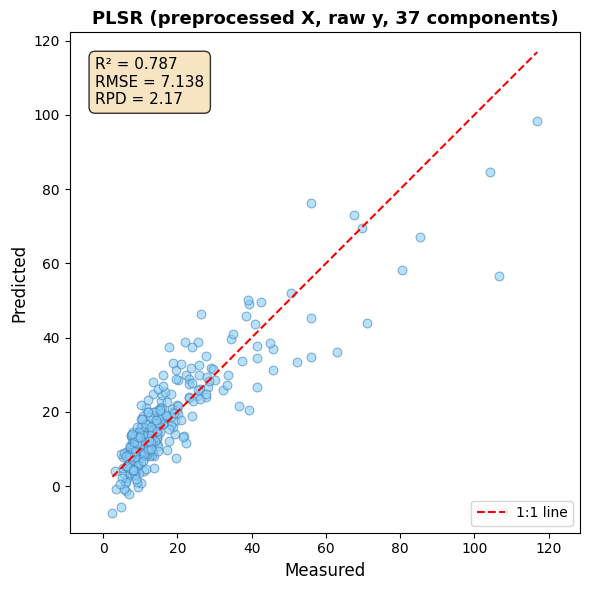

In [18]:
plot_metrics(
    y_test,
    y_pred_proc_x,
    "PLSR (preprocessed X, raw y, 29 components)",
)

After applying log (1 + x), the model stopped to systematically underpredict the high SOC values but the variance of high SOC samples prediction is high.

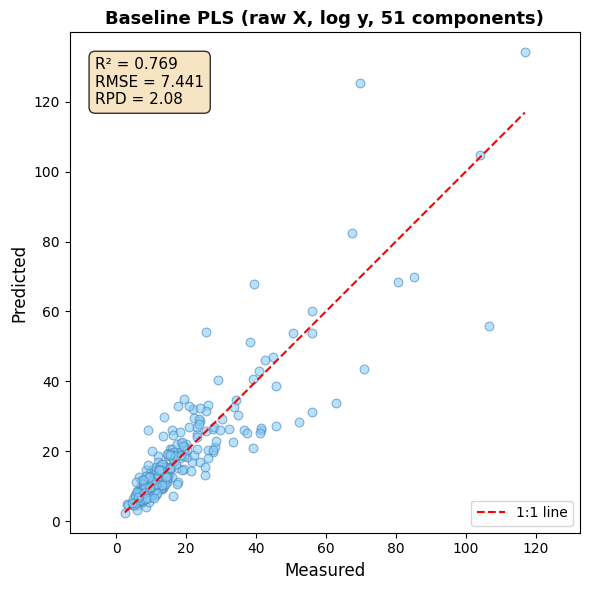

In [20]:
plot_metrics(
    y_test,
    np.expm1(y_pred_log_y),
    "Baseline PLS (raw X, log y, 59 components)",
)

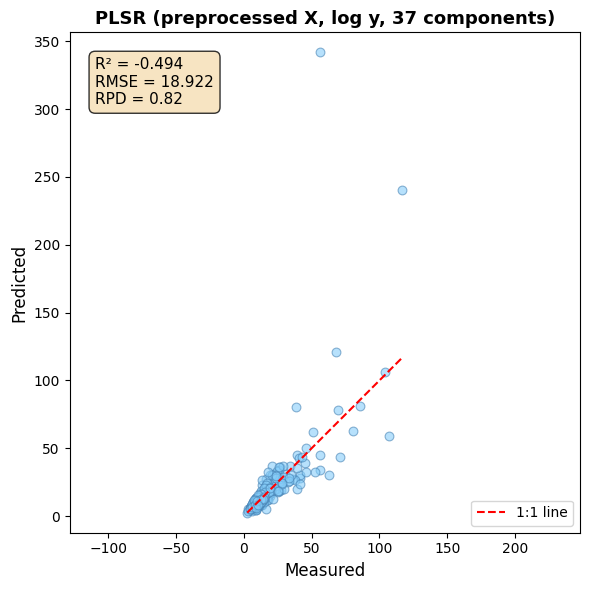

In [21]:
plot_metrics(
    y_test,
    np.expm1(y_pred_log_y_proc_x),
    "PLSR (preprocessed X, log y, 37 components)",
)

AUC threshold: 512.8204
Train — Learner A (low):    84  Learner B (high): 1170
Test  — Learner A (low):    20  Learner B (high): 294


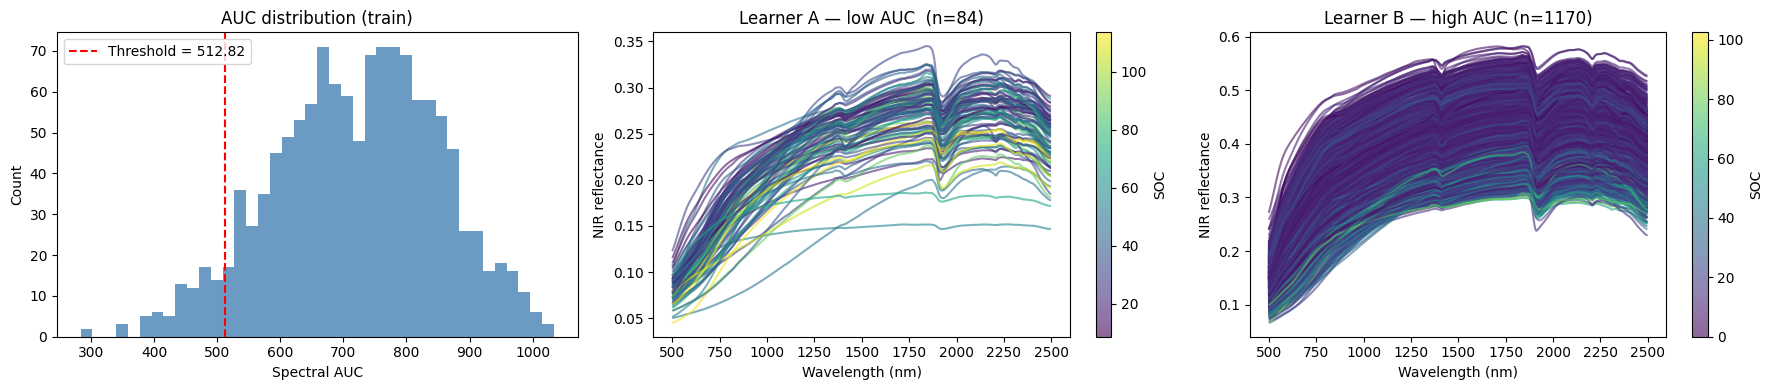

In [30]:
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

wavelengths = s.columns[1:].values.astype(float)

# Area under the reflectance curve for each sample
auc_train = np.trapz(X_train_raw, wavelengths, axis=1)
auc_test  = np.trapz(X_test_raw,  wavelengths, axis=1)

# Otsu threshold on training AUC
auc_threshold = threshold_otsu(auc_train) - 200 # Adjusted threshold to create a more balanced split

mask_train_low  = auc_train <= auc_threshold
mask_train_high = auc_train >  auc_threshold
mask_test_low   = auc_test  <= auc_threshold
mask_test_high  = auc_test  >  auc_threshold

print(f"AUC threshold: {auc_threshold:.4f}")
print(f"Train — Learner A (low):  {mask_train_low.sum():4d}  Learner B (high): {mask_train_high.sum()}")
print(f"Test  — Learner A (low):  {mask_test_low.sum():4d}  Learner B (high): {mask_test_high.sum()}")

X_train_low,  y_train_low  = X_train_raw[mask_train_low],  y_train[mask_train_low]
X_train_high, y_train_high = X_train_raw[mask_train_high], y_train[mask_train_high]
X_test_low,   y_test_low   = X_test_raw[mask_test_low],    y_test[mask_test_low]
X_test_high,  y_test_high  = X_test_raw[mask_test_high],   y_test[mask_test_high]

X_train_proc_low,  y_train_proc_low  = X_train_processed[mask_train_low],  y_train[mask_train_low]
X_train_proc_high, y_train_proc_high = X_train_processed[mask_train_high], y_train[mask_train_high]
X_test_proc_low,   y_test_proc_low   = X_test_processed[mask_test_low],    y_test[mask_test_low]
X_test_proc_high,  y_test_proc_high  = X_test_processed[mask_test_high],   y_test[mask_test_high]

# ── plot: AUC histogram + spectra for each learner ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(auc_train, bins=40, color='steelblue', alpha=0.8)
axes[0].axvline(auc_threshold, color='red', linestyle='--',
                label=f'Threshold = {auc_threshold:.2f}')
axes[0].set_xlabel('Spectral AUC')
axes[0].set_ylabel('Count')
axes[0].set_title('AUC distribution (train)')
axes[0].legend()

for ax, X_sub, y_sub, title in [
    (axes[1], X_train_low,  y_train_low,
     f'Learner A — low AUC  (n={mask_train_low.sum()})'),
    (axes[2], X_train_high, y_train_high,
     f'Learner B — high AUC (n={mask_train_high.sum()})'),
]:
    norm = mcolors.Normalize(vmin=y_sub.min(), vmax=y_sub.max())
    segs = [np.column_stack([wavelengths, row]) for row in X_sub]
    lc = LineCollection(segs, cmap='viridis', norm=norm, alpha=0.6)
    lc.set_array(y_sub)
    ax.add_collection(lc)
    ax.autoscale()
    plt.colorbar(lc, ax=ax, label='SOC')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('NIR reflectance')
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [23]:
grid_y_low = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_y_low.fit(X_train_low, y_train_low)

grid_y_high = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_y_high.fit(X_train_high, y_train_high)

Fitting 10 folds for each of 60 candidates, totalling 600 fits


Fitting 10 folds for each of 60 candidates, totalling 600 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'pls__n_components': range(1, 61)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,38


In [31]:
grid_proc_x_y_low = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_proc_x_y_low.fit(X_train_proc_low, y_train_proc_low)

grid_proc_x_y_high = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_proc_x_y_high.fit(X_train_proc_high, y_train_proc_high)

Fitting 10 folds for each of 60 candidates, totalling 600 fits
Fitting 10 folds for each of 60 candidates, totalling 600 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'pls__n_components': range(1, 61)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,26


In [27]:
grid_y_low.best_params_, grid_y_high.best_params_

({'pls__n_components': 10}, {'pls__n_components': 38})

In [32]:
grid_proc_x_y_low.best_params_, grid_proc_x_y_high.best_params_

({'pls__n_components': 7}, {'pls__n_components': 26})

In [35]:
y_test_low_pred = grid_y_low.predict(X_test_low)
y_test_high_pred = grid_y_high.predict(X_test_high)

y_test_low_pred_proc_x = grid_proc_x_y_low.predict(X_test_proc_low)
y_test_high_pred_proc_x = grid_proc_x_y_high.predict(X_test_proc_high)

In [36]:
y_test_low_high_pred_concat = np.hstack((y_test_low_pred, y_test_high_pred))
y_test_gt = np.hstack((y_test_low, y_test_high))

y_test_low_high_pred_proc_x_concat = np.hstack((y_test_low_pred_proc_x, y_test_high_pred_proc_x))

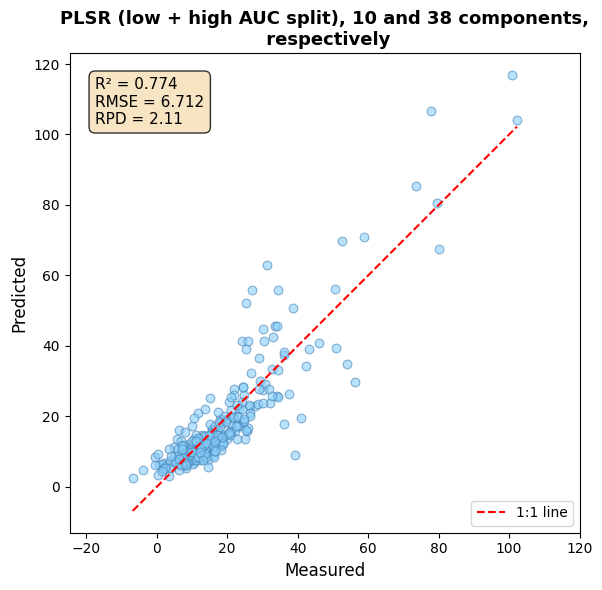

In [40]:
plot_metrics(
    y_test_low_high_pred_concat,
    y_test_gt,
    "PLSR (low + high AUC split), 10 and 38 components,\n respectively",
)

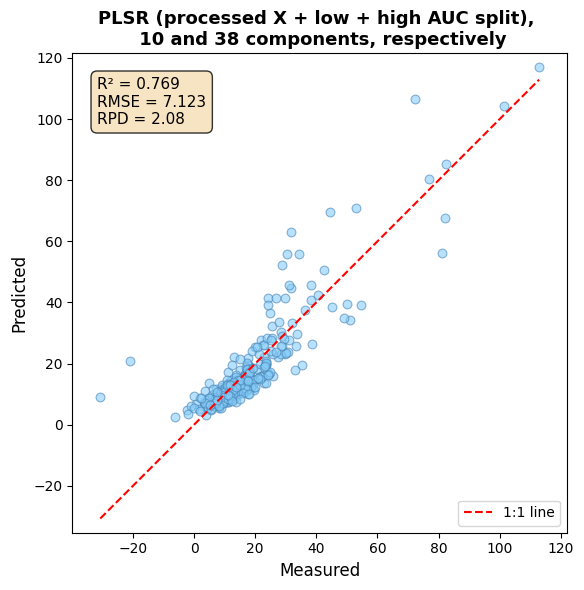

In [39]:
plot_metrics(
    y_test_low_high_pred_proc_x_concat,
    y_test_gt,
    "PLSR (processed X + low + high AUC split), \n 10 and 38 components, respectively",
)

## Ensemble (Stacking) using predictions from all models

In [41]:
# Save PLSR predictions for ensemble
# --- Best PLSR: preprocessed X, raw y (29 components) ---
pslr_train_raw_y = grid_proc_x.best_estimator_.predict(X_train_processed).ravel()
pslr_test_raw_y = y_pred_proc_x.ravel()

# --- Best PLSR: preprocessed X, log y (37 components) → expm1 back ---
pslr_train_log_y = np.expm1(grid_proc_x_log_y.best_estimator_.predict(X_train_processed).ravel())
pslr_test_log_y = np.expm1(y_pred_log_y_proc_x.ravel())

np.savez_compressed(
    "data/predictions/pslr_snv_sg1_preds.npz",
    pred_train=pslr_train_raw_y,
    pred_test=pslr_test_raw_y,
)
print(f"PLSR (proc X, raw y):  train {pslr_train_raw_y.shape}, test {pslr_test_raw_y.shape}")
print(f"PLSR (proc X, log y):  train {pslr_train_log_y.shape}, test {pslr_test_log_y.shape}")

# --- AUC-split PLSR: reconstruct full predictions ---
# Use preprocessed-X split models (grid_proc_x_y_low, grid_proc_x_y_high)
pslr_auc_train = np.empty(len(y_train))
pslr_auc_train[mask_train_low] = grid_proc_x_y_low.best_estimator_.predict(X_train_proc_low).ravel()
pslr_auc_train[mask_train_high] = grid_proc_x_y_high.best_estimator_.predict(X_train_proc_high).ravel()

pslr_auc_test = np.empty(len(y_test))
pslr_auc_test[mask_test_low] = grid_proc_x_y_low.best_estimator_.predict(X_test_proc_low).ravel()
pslr_auc_test[mask_test_high] = grid_proc_x_y_high.best_estimator_.predict(X_test_proc_high).ravel()

np.savez_compressed(
    "data/predictions/pslr_auc_split_preds.npz",
    pred_train=pslr_auc_train,
    pred_test=pslr_auc_test,
)
print(f"PLSR AUC-split:        train {pslr_auc_train.shape}, test {pslr_auc_test.shape}")

PLSR (proc X, raw y):  train (1254,), test (314,)
PLSR (proc X, log y):  train (1254,), test (314,)
PLSR AUC-split:        train (1254,), test (314,)


In [45]:
# Load all model predictions and stack into meta-features
model_files = {
    "SVR":             "data/predictions/svr_snv_sg1_preds.npz",
    "AutoGluon":       "data/predictions/gluon_snv_sg1_preds.npz",
    "AutoGluon_logY":  "data/predictions/gluon_snv_sg1_y_log_preds.npz",
    "FCN":             "data/predictions/fcn_snv_sg1_preds.npz",
    "PLSR":            "data/predictions/pslr_snv_sg1_preds.npz",
    "PLSR_AUC_split":  "data/predictions/pslr_auc_split_preds.npz",
}

train_preds, test_preds = {}, {}
for name, path in model_files.items():
    d = np.load(path)
    train_preds[name] = d["pred_train"].ravel()
    test_preds[name] = d["pred_test"].ravel()
    print(f"{name:20s}  train: {train_preds[name].shape}  test: {test_preds[name].shape}")

# Also add PLSR log-y (already computed above, not saved separately)
# train_preds["PLSR_logY"] = pslr_train_log_y
# test_preds["PLSR_logY"] = pslr_test_log_y
# print(f"{'PLSR_logY':20s}  train: {pslr_train_log_y.shape}  test: {pslr_test_log_y.shape}")

model_names = list(train_preds.keys())
X_meta_train = np.column_stack([train_preds[n] for n in model_names])
X_meta_test = np.column_stack([test_preds[n] for n in model_names])
print(f"\nMeta features: {X_meta_train.shape[1]} models")
print(f"X_meta_train: {X_meta_train.shape}, X_meta_test: {X_meta_test.shape}")

SVR                   train: (1254,)  test: (314,)
AutoGluon             train: (1254,)  test: (314,)
AutoGluon_logY        train: (1254,)  test: (314,)
FCN                   train: (1254,)  test: (314,)
PLSR                  train: (1254,)  test: (314,)
PLSR_AUC_split        train: (1254,)  test: (314,)

Meta features: 6 models
X_meta_train: (1254, 6), X_meta_test: (314, 6)


In [46]:
# Train stacking meta-learner
from sklearn.linear_model import RidgeCV

y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# RidgeCV with 10-fold CV
ridge = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=10)
ridge.fit(X_meta_train, y_train_flat)
print(f"RidgeCV best alpha: {ridge.alpha_:.4f}")
print(f"Ridge coefficients: {dict(zip(model_names, ridge.coef_.round(3)))}")
print(f"Ridge intercept:    {ridge.intercept_:.3f}")

y_pred_ridge_train = ridge.predict(X_meta_train)
y_pred_ridge_test = ridge.predict(X_meta_test)

# Simple mean baseline
y_pred_mean_train = X_meta_train.mean(axis=1)
y_pred_mean_test = X_meta_test.mean(axis=1)

# Print comparison
from sklearn.metrics import r2_score, mean_squared_error

results = []
for name, y_pred in [("Ridge Ensemble", y_pred_ridge_test), ("Mean Ensemble", y_pred_mean_test)]:
    r2 = r2_score(y_test_flat, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred))
    rpd = np.std(y_test_flat) / rmse
    results.append((name, r2, rmse, rpd))

# Individual model results for comparison
for name in model_names:
    y_pred = test_preds[name]
    r2 = r2_score(y_test_flat, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred))
    rpd = np.std(y_test_flat) / rmse
    results.append((name, r2, rmse, rpd))

print(f"\n{'Model':<20s}  {'R²':>6s}  {'RMSE':>7s}  {'RPD':>5s}")
print("-" * 45)
for name, r2, rmse, rpd in sorted(results, key=lambda x: -x[1]):
    print(f"{name:<20s}  {r2:6.3f}  {rmse:7.3f}  {rpd:5.2f}")

RidgeCV best alpha: 1048.1131
Ridge coefficients: {'SVR': 0.65, 'AutoGluon': 0.557, 'AutoGluon_logY': -0.098, 'FCN': 0.039, 'PLSR': -0.062, 'PLSR_AUC_split': -0.019}
Ridge intercept:    -0.924

Model                     R²     RMSE    RPD
---------------------------------------------
Mean Ensemble          0.861    5.776   2.68
AutoGluon              0.853    5.938   2.61
Ridge Ensemble         0.827    6.436   2.40
FCN                    0.820    6.568   2.36
AutoGluon_logY         0.806    6.812   2.27
PLSR_AUC_split         0.788    7.123   2.17
PLSR                   0.787    7.138   2.17
SVR                    0.756    7.649   2.02


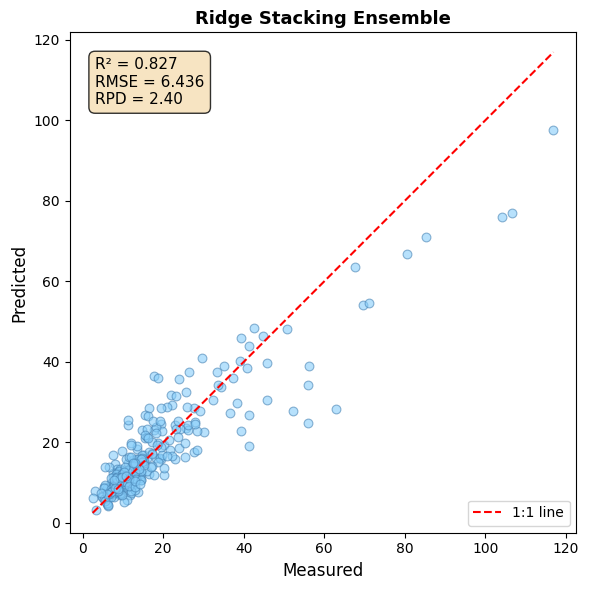

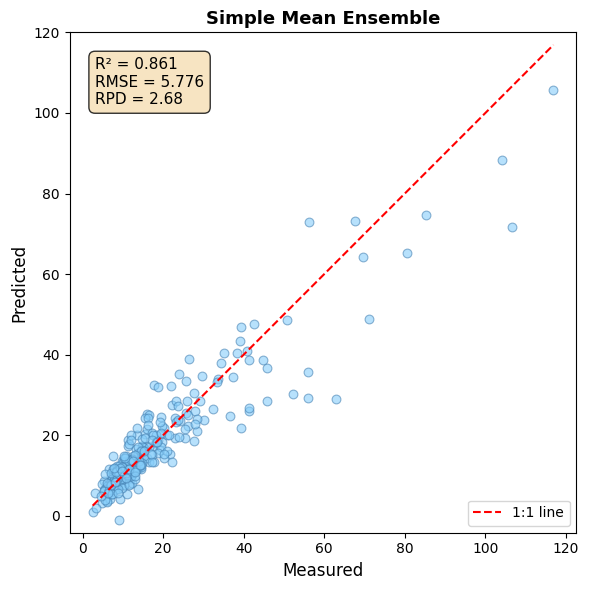

In [47]:
# Evaluate and plot
plot_metrics(y_test_flat, y_pred_ridge_test, "Ridge Stacking Ensemble")
plot_metrics(y_test_flat, y_pred_mean_test, "Simple Mean Ensemble")